In [1]:
pip install pytrends


Note: you may need to restart the kernel to use updated packages.


In [1]:
from pytrends.request import TrendReq
import pandas as pd



In [ ]:
from pytrends.request import TrendReq
import pandas as pd

def get_trend(time, key_words, location):
    '''
    time(str) is the duration of time we are intrested, in the format of 'xxxx-xx-xx yyyy-yy-yy' inclusive
    where xxxx-xx-xx is the start and yyyy-yy-yy is the end
    key_words(list[str]) list of strings we are intrested looking up the trend
    location(str) the searches location we are intrested in

    '''
    pytrends = TrendReq(hl='en-US')

    pytrends.build_payload(
        key_words,
        timeframe=time,
        geo=location
    )

    data = pytrends.interest_over_time()
    data.to_csv(f"{key_words[0]}.csv")
    
import matplotlib.pyplot as plt

def plot_trends(filename, incident_date):
    df = pd.read_csv(filename)

    # Convert date column
    df['date'] = pd.to_datetime(df['date'])
    incident_date = pd.to_datetime(incident_date)

    # Trend columns (exclude these)
    trend_cols = [c for c in df.columns if c not in ['date', 'youtube', 'isPartial']]

    # Find column with highest peak
    peak_col = df[trend_cols].max().idxmax()

    # Get row closest to incident date
    row = df.iloc[(df['date'] - incident_date).abs().argsort()[:1]]

    # Values at incident
    incident_trend = row[peak_col].values[0]
    incident_x = row['date'].values[0]

    # Plot
    plt.figure()
    plt.plot(df['date'], df[peak_col], label=peak_col)
    plt.plot(df['date'], df['youtube'], label='youtube')

    # Vertical incident line
    plt.axvline(x=incident_date, linestyle='--', label='incident')

    # Incident points
    plt.scatter(incident_x, incident_trend)

    plt.xlabel("Date")
    plt.ylabel("Search Interest")
    plt.title(f"{peak_col} vs YouTube Search Over Time")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()





In [ ]:
print()

3

In [ ]:
time = '2026-02-21 2026-03-8'
key_words = ['Iran', 'US strikes Iran', 'US invades Iran', 'US bombs Iran','youtube']
geo = 'US'

get_trend(time, key_words, geo)
plot_trends('Iran.csv', '2026-02-28')

TooManyRequestsError: The request failed: Google returned a response with code 429

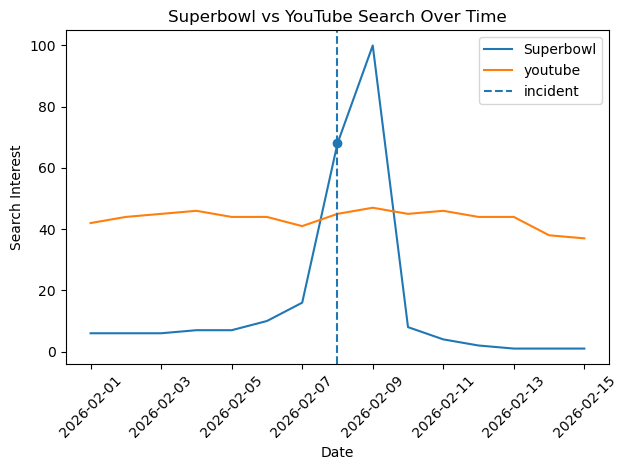

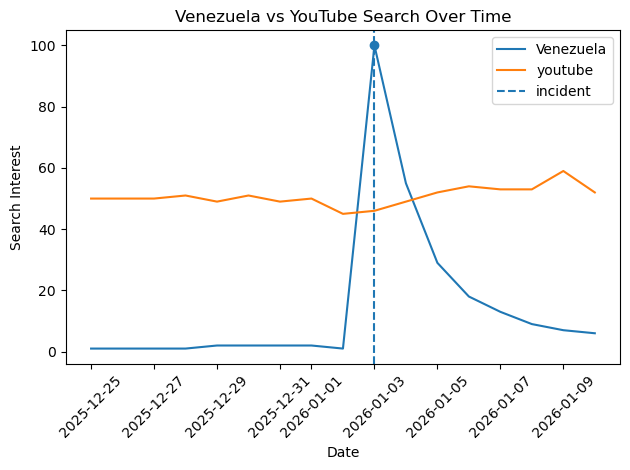

In [2]:
pip install trendspyg


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 14.5 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.3.0
    Uninstalling urllib3-2.3.0:
      Successfully uninstalled urllib3-2.3.0
  Attempting uninstall: typing_extensions
    Found existing installation: typing_extensions 4.12.2
    Uninstalling typing_extensions-4.12.2:
      Successfully uninstalled typing_extensions-4.12.2━━━━━━━━━━━ 2/9 [typing_extensions]
  Attempting uninstall: certifi━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/9 [outcome]sions]
    Found existing installation: certifi 2025.10.5━━━━━━━━━━━━ 3/9 [outcome]
    Uninstalling certifi-2025.10.5:m━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/9 [outcome]
      Successfully uninstalled certifi-2025.10.5━━━━━━━━━━━━━━ 3/9 [outcome]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [trendspyg]/9 [selenium]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from trendspyg import download_google_trends_rss

trends = download_google_trends_rss(geo='US')

for trend in trends[:500]:
    print(f"{trend['trend']} - {trend['traffic']}")
    if trend['news_articles']:
        print(f"  {trend['news_articles'][0]['headline']}")


lottery powerball winning numbers - 200+
  Powerball winning numbers for Monday, February 23, 2026
tropical cyclone horacio - 200+
  Tropical Cyclone Horacio: Earth’s first Category 5 tropical cyclone of 2026
panama canal ports - 2000+
  Panama cancels China-linked port deal, hands canal terminals to Maersk, MSC
bobby cannavale - 200+
  Inside Rose Byrne’s beautiful family life with Bobby Cannavale
pokemon 30th anniversary logo - 500+
  BoxLunch Celebrates 30 Years of POKÉMON With Adorable Product Launch
winter olympics gold medals - 500+
  Italy throws farewell party, passes Olympic torch to France
nbc renewals - 2000+
  NBC Renewal Status Report: ‘Chicago’ And ‘Law & Order’ Franchises, ‘The Hunting Party’, ‘Brilliant Minds’ & ‘Stumble’
scottie - 2000+
  Scottie Scheffler's first-round struggles prove capability of world's No. 1 golfer -- despite lack of wins
taylor tomlinson - 1000+
  Jimmy Kimmel Live Schedule for the Week of 2/16/2026
david carradine - 5000+
  David Carradine’s leg